# Baseline: Кредитный скоринг

План:
1. Загрузка и первый взгляд
2. Целевая переменная и дисбаланс
3. Пропуски и типы
4. Немного разведки
5. Разбиение на train и test
6. Baseline: Pipeline с логистической регрессией
7. CatBoost с ранней остановкой
8. Порог под бизнес-требование
9. Сохранение артефакта с метаданными
10. Загрузка и предсказание на одной строке

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
                             average_precision_score,
                             f1_score,
                             precision_recall_curve,
                             precision_score,
                             recall_score,
                             roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = Path("data/credit_score.csv")
ARTIFACTS = Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)

# 1. Загрузка датасета

In [2]:
RENAME = {
    "RevolvingUtilizationOfUnsecuredLines": "unsecured_lines",
    "NumberOfTime30-59DaysPastDueNotWorse": "past_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "credit_lines",
    "NumberOfTimes90DaysLate": "past_90",
    "NumberRealEstateLoansOrLines": "real_estate",
    "NumberOfTime60-89DaysPastDueNotWorse": "past_60_89",
    "NumberOfDependents": "dependents",
}

df = pd.read_csv(DATA_PATH, index_col=0)
df = df.rename(columns=RENAME)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,unsecured_lines,age,past_30_59,debt_ratio,monthly_income,credit_lines,past_90,real_estate,past_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   SeriousDlqin2yrs  150000 non-null  int64  
 1   unsecured_lines   150000 non-null  float64
 2   age               150000 non-null  int64  
 3   past_30_59        150000 non-null  int64  
 4   debt_ratio        150000 non-null  float64
 5   monthly_income    120269 non-null  float64
 6   credit_lines      150000 non-null  int64  
 7   past_90           150000 non-null  int64  
 8   real_estate       150000 non-null  int64  
 9   past_60_89        150000 non-null  int64  
 10  dependents        146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


# 2. Целевая переменная и дисбаланс

Таргет - SeriousDlqin2yrs. Бинарная переменная со значениями 0/1

In [4]:
rate = df["SeriousDlqin2yrs"].mean()
print(f"Заёмщиков, вышедших на просрочку 90+ дней: {df['SeriousDlqin2yrs'].sum()} из {len(df)} ({rate:.1%})")
df["SeriousDlqin2yrs"].value_counts()

Заёмщиков, вышедших на просрочку 90+ дней: 10026 из 150000 (6.7%)


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Такие длительные просрочки допустили лишь 6,7% клиентов

## 3. Пропуски и типы

Есть 1 строчка с пропуском возраста, ее удаление ни к каким последствиям не приведет
И нужно обратить внимание на past_30_59/past_60_89/past_90. У человека не может быть по 96/98 просрочек, чисто по логике это просто специальный внутренний код у банка. Таких ячеек немного, думаю можно удалить

In [5]:
df[df['age'] == 0]

,SeriousDlqin2yrs,unsecured_lines,age,past_30_59,debt_ratio,monthly_income,credit_lines,past_90,real_estate,past_60_89,dependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [6]:
mask = (df['past_30_59'].isin([96, 98]) | 
        df['past_60_89'].isin([96, 98]) |
        df['past_90'].isin([96, 98]))

df[mask].head()

,SeriousDlqin2yrs,unsecured_lines,age,past_30_59,debt_ratio,monthly_income,credit_lines,past_90,real_estate,past_60_89,dependents
1734,1,1.0,27,98,0.0,2700.0,0,98,0,98,0.0
2287,0,1.0,22,98,0.0,NaN,0,98,0,98,0.0
3885,0,1.0,38,98,12.0,NaN,0,98,0,98,0.0
4418,0,1.0,21,98,0.0,0.0,0,98,0,98,0.0
4706,0,1.0,21,98,0.0,2000.0,0,98,0,98,0.0


In [7]:
total_mask = (df['past_30_59'].isin([96, 98]) | 
              df['past_60_89'].isin([96, 98]) |
              df['past_90'].isin([96, 98]) |
              df['age'] == 0)

print("Некорректных строчек в датасете всего", len(df[mask]))

df = df[~total_mask]

Некорректных строчек в датасете всего 269


In [8]:
no_income_mask = df['monthly_income'].isna()
print("Ячеек с пустым ежемесячным доходом всего", len(df[no_income_mask]))
df[no_income_mask].head()

Ячеек с пустым ежемесячным доходом всего 29731


,SeriousDlqin2yrs,unsecured_lines,age,past_30_59,debt_ratio,monthly_income,credit_lines,past_90,real_estate,past_60_89,dependents
7,0,0.305682,57,0,5710.0,NaN,8,0,3,0,0.0
9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
17,0,0.061086,78,0,2058.0,NaN,10,0,2,0,0.0
33,0,0.083418,62,0,977.0,NaN,6,0,1,0,0.0
42,0,0.072898,81,0,75.0,NaN,7,0,0,0,0.0


Таких пропусков немало. На самом деле наталкивает на мысль, что стоит ввести дополнительную фичу `monthly_income_missing` как индикатор для бустинга 

In [9]:
df['monthly_income_missing'] = no_income_mask.astype(int)

# 3. EDA

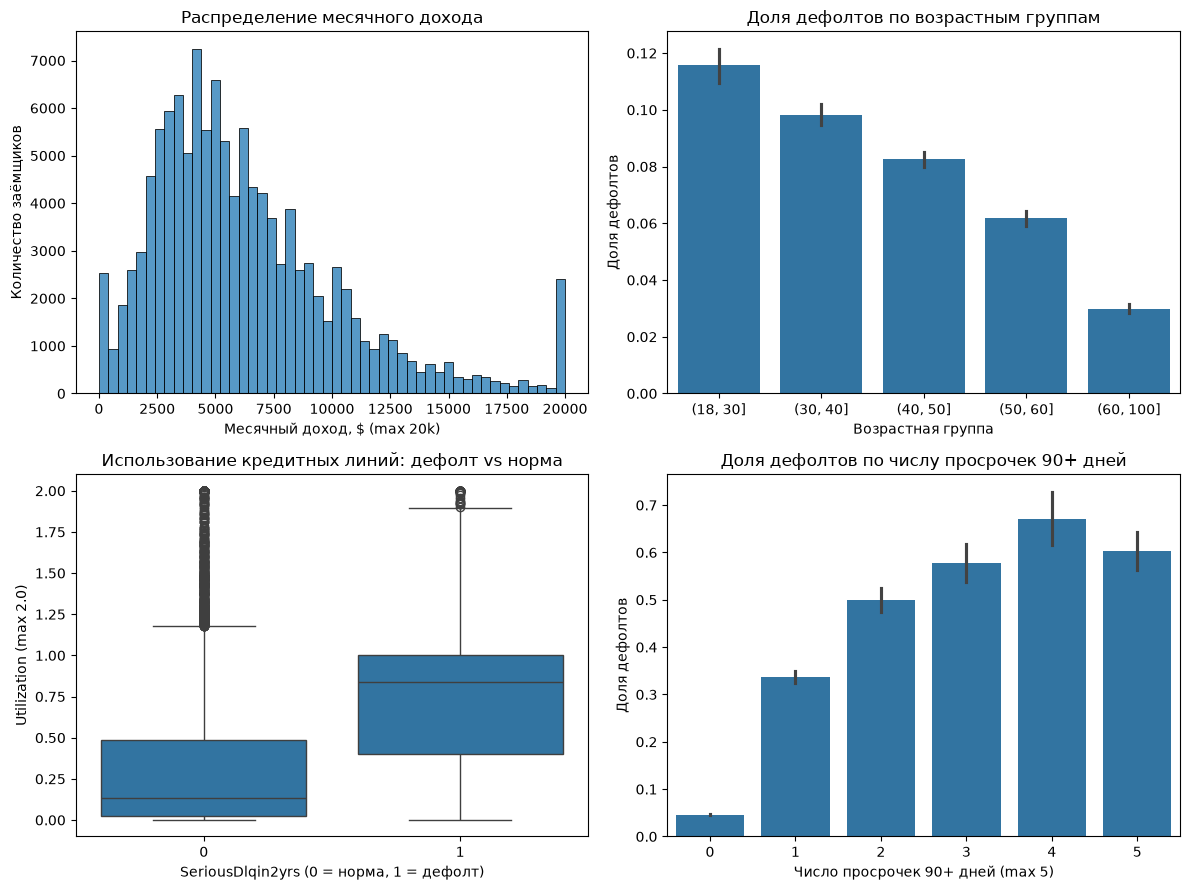

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df["monthly_income"].clip(upper=20000), bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Распределение месячного дохода")
axes[0, 0].set_xlabel("Месячный доход, $ (max 20k)")
axes[0, 0].set_ylabel("Количество заёмщиков")


age_bins = pd.cut(df["age"], bins=[18, 30, 40, 50, 60, 100])
sns.barplot(x=age_bins, y=df["SeriousDlqin2yrs"], ax=axes[0, 1])
axes[0, 1].set_title("Доля дефолтов по возрастным группам")
axes[0, 1].set_xlabel("Возрастная группа")
axes[0, 1].set_ylabel("Доля дефолтов")
axes[0, 1].tick_params(axis="x")


sns.boxplot(
    x=df["SeriousDlqin2yrs"],
    y=df["unsecured_lines"].clip(upper=2),
    ax=axes[1, 0],
)
axes[1, 0].set_title("Использование кредитных линий: дефолт vs норма")
axes[1, 0].set_xlabel("SeriousDlqin2yrs (0 = норма, 1 = дефолт)")
axes[1, 0].set_ylabel("Utilization (max 2.0)")


sns.barplot(x=df["past_90"].clip(upper=5), y=df["SeriousDlqin2yrs"], ax=axes[1, 1])
axes[1, 1].set_title("Доля дефолтов по числу просрочек 90+ дней")
axes[1, 1].set_xlabel("Число просрочек 90+ дней (max 5)")
axes[1, 1].set_ylabel("Доля дефолтов")

plt.tight_layout()
plt.show()

Доход сильно скошен вправо с пиком около 4-5 тысяч и длинным хвостом — median для импутации, а не mean, обосновано графиком, а не только общим правилом.

Доля дефолтов монотонно падает с возрастом: ~12% в группе 18-30 против ~3% в группе 60+. Возраст — рабочий признак, но не самый сильный.

Utilization резко различается по классам: медиана ~0.13 у нормальных заёмщиков против ~0.83 у дефолтных, плюс сильно больший разброс у дефолтных — ожидаемо один из главных признаков в обеих моделях.

Самая крутая зависимость — по числу просрочек 90+ дней: доля дефолта растёт с ~4% при 0 просрочек до ~60-70% при 3-4 просрочках. Это самый сильный одиночный предиктор в датасете, и это ожидаемо: прошлые просрочки — прямой предиктор будущих.

## 5. Разбиение на train и test

Стратифицированное разбиение 80/20: доля оттока в обеих частях одинаковая.

In [11]:
TARGET = "SeriousDlqin2yrs"
DROP = [TARGET]
X = df.drop(columns=DROP)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print(f"доля дефолта: train {y_train.mean():.3%}, test {y_test.mean():.3%}")

(119999, 11) (30000, 11)
доля дефолта: train 6.684%, test 6.683%


In [12]:
impute_median_cols = ["monthly_income", "dependents"]
passthrough_cols = [c for c in X.columns if c not in impute_median_cols]

print("колонки, заполняемые медианой:", impute_median_cols)
print("остальные переменные:", passthrough_cols)

колонки, заполняемые медианой: ['monthly_income', 'dependents']
остальные переменные: ['unsecured_lines', 'age', 'past_30_59', 'debt_ratio', 'credit_lines', 'past_90', 'real_estate', 'past_60_89', 'monthly_income_missing']


## 6. Baseline: Pipeline с логистической регрессией

In [13]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), impute_median_cols),
    ("passthrough", "passthrough", passthrough_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, C=1.0)),
])

logreg.fit(X_train, y_train)

def report(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    row = {
        "model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"precision@{threshold}": precision_score(y_true, pred),
        f"recall@{threshold}": recall_score(y_true, pred),
        f"F1@{threshold}": f1_score(y_true, pred),
    }
    return row

proba_lr = logreg.predict_proba(X_test)[:, 1]
results = [report("logreg", y_test, proba_lr, threshold=0.061)]
pd.DataFrame(results).round(3)

,model,ROC-AUC,PR-AUC,precision@0.061,recall@0.061,F1@0.061
0,logreg,0.712,0.242,0.112,0.697,0.193


## 7. CatBoost с ранней остановкой

In [14]:
from catboost import CatBoostClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
X_tr_cb, X_val_cb, X_test_cb = X_tr.copy(), X_val.copy(), X_test.copy()

cat = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
)
cat.fit(X_tr_cb, y_tr, eval_set=(X_val_cb, y_val), early_stopping_rounds=50)

print("лучшая итерация:", cat.get_best_iteration())
proba_cb = cat.predict_proba(X_test_cb)[:, 1]
results.append(report("catboost", y_test, proba_cb, threshold=0.093))
pd.DataFrame(results).round(3)

лучшая итерация: 371


,model,ROC-AUC,PR-AUC,precision@0.061,recall@0.061,F1@0.061,precision@0.093,recall@0.093,F1@0.093
0,logreg,0.712,0.242,0.112,0.697,0.193,NaN,NaN,NaN
1,catboost,0.870,0.405,NaN,NaN,NaN,0.266,0.702,0.385


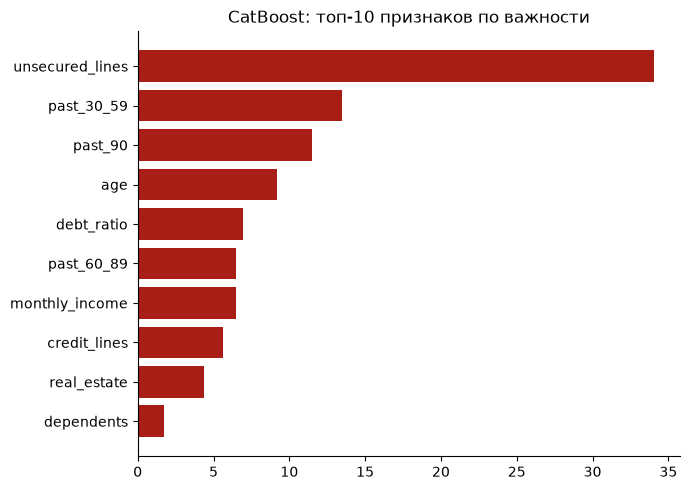

In [15]:
importances = pd.Series(cat.get_feature_importance(), index=X_tr_cb.columns).sort_values()
plt.figure(figsize=(7, 5))
plt.barh(importances.index[-10:], importances.values[-10:], color="#A81E17")
plt.title("CatBoost: топ-10 признаков по важности")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## 8. Порог под бизнес-требование

порог 0.094: recall 0.700, precision 0.267


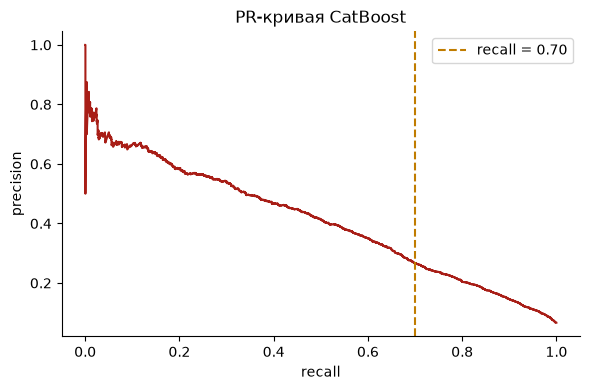

In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_cb)
mask = recall[:-1] >= 0.70
best_threshold_cb = thresholds[mask].max()
pred = (proba_cb >= best_threshold_cb).astype(int)
print(f"порог {best_threshold_cb:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="#A81E17")
plt.axvline(0.70, color="#C07C00", linestyle="--", label="recall = 0.70")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("PR-кривая CatBoost")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

порог 0.061: recall 0.700, precision 0.111


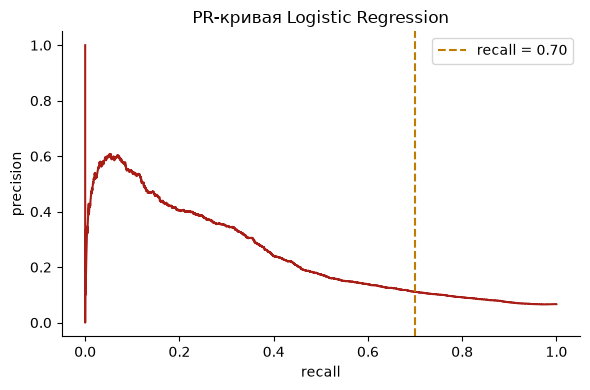

In [17]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_lr)
mask = recall[:-1] >= 0.70
best_threshold_lr = thresholds[mask].max()
pred = (proba_lr >= best_threshold_lr).astype(int)
print(f"порог {best_threshold_lr:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="#A81E17")
plt.axvline(0.70, color="#C07C00", linestyle="--", label="recall = 0.70")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("PR-кривая Logistic Regression")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## 9. Сохранение артефакта с метаданными

In [18]:
import catboost
import sklearn

metadata = {
    "model_name": "credit-baseline",
    "model_version": "0.1.0",
    "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
    "n_train": len(X_train),
    "features": list(X.columns),
    "impute_median_cols": impute_median_cols,
    "passthrough_cols": passthrough_cols,
    "threshold_cb": float(round(best_threshold_cb, 4)),
    "threshold_lr": float(round(best_threshold_lr, 4)),
    "metrics_test": {k: round(float(v), 4) for k, v in results[1].items() if k != "model"},
    "libs": {"pandas": pd.__version__, "scikit-learn": sklearn.__version__, "catboost": catboost.__version__},
}

joblib.dump({"pipeline": logreg, "metadata": {**metadata, "model_name": "credit-logreg"}},
            ARTIFACTS / "baseline_logreg.joblib")
cat.save_model(str(ARTIFACTS / "baseline_catboost.cbm"))
(ARTIFACTS / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=4), encoding="utf-8")

sorted(p.name for p in ARTIFACTS.iterdir())

['baseline_catboost.cbm', 'baseline_logreg.joblib', 'metadata.json']

## 10. Загрузка и предсказание на одной строке

In [19]:
bundle = joblib.load(ARTIFACTS / "baseline_logreg.joblib")
pipe, meta = bundle["pipeline"], bundle["metadata"]

payload = X_test.iloc[0].to_dict()
frame = pd.DataFrame([payload])[meta["features"]]

score = float(pipe.predict_proba(frame)[0, 1])
print(json.dumps({"score": round(score, 4),
                  "credit": bool(score >= meta["threshold_lr"]),
                  "model_version": meta["model_version"]}, ensure_ascii=False))

{"score": 0.0765, "credit": true, "model_version": "0.1.0"}


In [20]:
batch_score = pipe.predict_proba(X_test)[0, 1]
assert abs(batch_score - score) < 1e-9, "train-serve skew: одна строка и батч дают разные ответы"
print("одна строка и батч совпадают до 1e-9")

одна строка и батч совпадают до 1e-9
